# Feature Set Decision

This notebook explains why the final clustering input drops gender and degree dummy variables. It isolates the feature-set decision by comparing alternatives under the same StandardScaler setup.


## Decision Logic

1. Rebuild the previous 25-feature input in memory.
2. Rebuild the compact 20-feature business input in memory.
3. Compare both with K-Means `k=5` using the same scaler and settings.


## Imports


In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

sys.path.append("../src")

from clustering import compare_kmeans_feature_sets
from preprocessing import FINAL_MODEL_COLUMNS, clean_feature_values, scale_model_features


## Load Customer Features

The feature-set comparison starts from the readable customer-level feature table, not from the already-final processed modelling file.


In [2]:
customer_features = pd.read_csv("../data/processed/customer_features_info.csv")
clean_customer_features = clean_feature_values(customer_features)

validation = pd.DataFrame({
    "check": [
        "rows",
        "unique customer_id",
        "compact feature count",
        "missing values in compact columns",
    ],
    "value": [
        len(clean_customer_features),
        clean_customer_features["customer_id"].nunique(),
        len(FINAL_MODEL_COLUMNS),
        clean_customer_features[FINAL_MODEL_COLUMNS].isna().sum().sum(),
    ],
})
validation


,check,value
0,rows,33038
1,unique customer_id,33038
2,compact feature count,20
3,missing values in compact columns,0


## Build Feature Set Candidates

The previous feature set adds gender and degree dummy variables to the compact numeric business features. The compact feature set keeps only the 20 numeric business features.


In [3]:
compact_standard = scale_model_features(
    clean_customer_features,
    feature_columns=FINAL_MODEL_COLUMNS,
    scaler=StandardScaler(),
)

dummy_columns = [
    "customer_gender_female",
    "degree_level_Bsc",
    "degree_level_Msc",
    "degree_level_Phd",
    "degree_level_Unknown",
]

categorical_dummies = pd.get_dummies(
    clean_customer_features[["customer_gender", "degree_level"]],
    drop_first=False,
    dtype=int,
)
categorical_dummies = categorical_dummies.reindex(columns=dummy_columns, fill_value=0)

previous_with_categorical_dummies = pd.concat(
    [compact_standard, categorical_dummies],
    axis=1,
)

feature_sets = {
    "previous_with_categorical_dummies": previous_with_categorical_dummies,
    "compact_business_set": compact_standard,
}

pd.DataFrame(
    {"feature_set": name, "feature_count": features.shape[1]}
    for name, features in feature_sets.items()
)


,feature_set,feature_count
0,previous_with_categorical_dummies,25
1,compact_business_set,20


## Compare Feature Sets With k=5


In [4]:
feature_set_metrics = compare_kmeans_feature_sets(
    feature_sets,
    k=5,
    random_state=42,
    n_init=50,
    sample_size=10000,
)

feature_set_metrics = feature_set_metrics[[
    "feature_set_variant",
    "k",
    "random_state",
    "n_features",
    "inertia",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_size",
    "max_cluster_size",
    "min_cluster_percentage",
    "max_cluster_percentage",
]]

feature_set_metrics.to_csv("../outputs/feature_set_sensitivity_metrics.csv", index=False)
feature_set_metrics.sort_values("silhouette_score", ascending=False)


,feature_set_variant,k,random_state,n_features,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
1,compact_business_set,5,42,20,450976.067804,0.141156,3841.553195,2.057096,2233,10769,6.758884,32.595799
0,previous_with_categorical_dummies,5,42,25,478598.468556,0.135222,3650.808841,2.108630,2234,10841,6.761911,32.813730


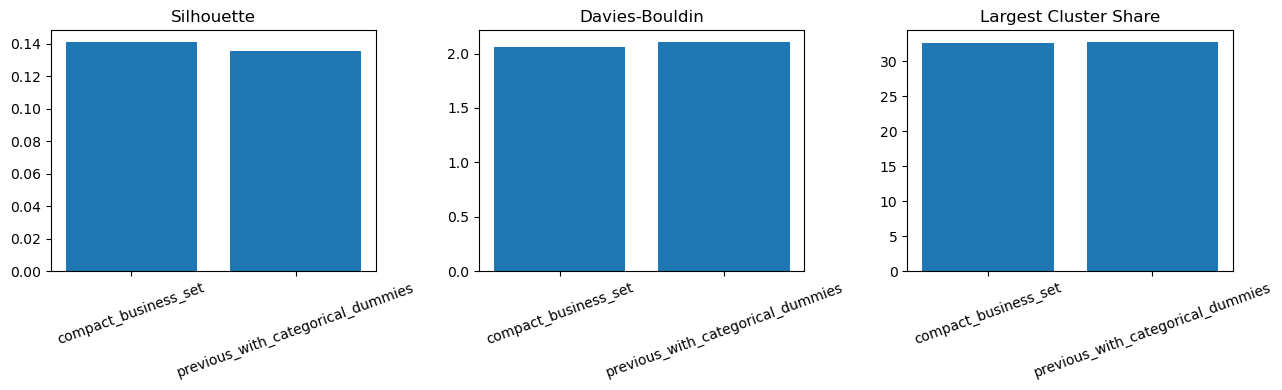

In [5]:
plot_data = feature_set_metrics.sort_values("silhouette_score", ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(plot_data["feature_set_variant"], plot_data["silhouette_score"])
axes[0].set_title("Silhouette")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(plot_data["feature_set_variant"], plot_data["davies_bouldin_score"])
axes[1].set_title("Davies-Bouldin")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(plot_data["feature_set_variant"], plot_data["max_cluster_percentage"])
axes[2].set_title("Largest Cluster Share")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Recommendation


In [6]:
previous = feature_set_metrics.loc[
    feature_set_metrics["feature_set_variant"] == "previous_with_categorical_dummies"
].iloc[0]
compact = feature_set_metrics.loc[
    feature_set_metrics["feature_set_variant"] == "compact_business_set"
].iloc[0]

recommendation = pd.DataFrame([
    {
        "recommended_feature_set": "compact_business_set",
        "recommended_k": 5,
        "reason": (
            f"The compact set improves silhouette from {previous['silhouette_score']:.3f} "
            f"to {compact['silhouette_score']:.3f} and improves Davies-Bouldin from "
            f"{previous['davies_bouldin_score']:.3f} to {compact['davies_bouldin_score']:.3f}."
        ),
        "dropped_features": "customer_gender and degree-level dummy columns",
        "basket_policy": "Basket features remain excluded from clustering.",
        "decision": "Use the compact business feature set for the final model.",
    }
])

recommendation.to_csv("../outputs/feature_set_sensitivity_recommendation.csv", index=False)
recommendation


,recommended_feature_set,recommended_k,reason,dropped_features,basket_policy,decision
0,compact_business_set,5,The compact set improves silhouette from 0.135...,customer_gender and degree-level dummy columns,Basket features remain excluded from clustering.,Use the compact business feature set for the f...


## Conclusion

The compact business feature set is clearer and performs better than the previous dummy-enhanced feature set. Gender and degree are kept out of the final clustering input. Basket data is still reserved for post-clustering profiling and promotion analysis.
